# Analisis Sentimen Ulasan Destinasi Wisata di Madura Menggunakan IndoBertweet dan Indobert

## 1. Import Libraries

### Persiapan Lingkungan Kerja (*Environment Setup*) dan Import Library

Tahap pertama dalam *pipeline* ini adalah memuat seluruh *library* dan modul Python yang dibutuhkan untuk pemrosesan data, pemodelan *Deep Learning*, hingga evaluasi metrik. Untuk memudahkan pemahaman, modul yang diimpor dibagi ke dalam beberapa kategori utama:

**1. Modul Sistem dan Utilitas Dasar**
* `os`, `time`, `socket`: Digunakan untuk manajemen sistem operasi, perhitungan waktu eksekusi, dan pengaturan jaringan.
* `gc` (*Garbage Collector*): Sangat krusial untuk manajemen memori, berfungsi membersihkan sisa variabel di RAM/VRAM agar sistem tidak *crash* (*Out of Memory*) saat melakukan *looping* pemodelan.
* `warnings`: Digunakan untuk menonaktifkan peringatan (*warning*) bawaan Python agar *output* terminal tetap bersih dan mudah dibaca.

**2. Pemrosesan Teks dan Normalisasi (NLP)**
* `re` (*Regular Expression*): Mesin utama untuk mencari, memanipulasi, dan membersihkan teks dari karakter yang tidak diinginkan (seperti URL, angka, dan tagar).
* `string`: Membantu dalam mengidentifikasi dan membuang tanda baca (*punctuation*).
* `unicodedata`: Digunakan untuk menstandarkan karakter teks dan membuang aksen/diakritik (Normalisasi Unicode).
* `Counter`: Struktur data dari modul `collections` untuk menghitung frekuensi kemunculan kata secara cepat dan efisien.

**3. Manipulasi Data dan Visualisasi**
* `pandas` & `numpy`: Modul standar untuk manipulasi data tabular (DataFrame) dan komputasi array matematis.
* `matplotlib.pyplot` & `seaborn`: Digunakan untuk membuat visualisasi grafik yang menarik, seperti distribusi rating dan komposisi kelas sentimen.

**4. Kerangka Kerja Deep Learning (PyTorch)**
* `torch` & `torch.nn`: Mesin utama *framework* PyTorch untuk membangun dan mengeksekusi arsitektur *neural network*.
* `Dataset`, `DataLoader`: Digunakan untuk membungkus data teks menjadi *batch* yang siap disuapkan ke dalam model.
* `AdamW`: Algoritma optimasi tingkat lanjut yang dilengkapi dengan *weight decay* untuk mencegah *overfitting* saat *fine-tuning* model Transformer.
* `autocast`, `GradScaler`: Komponen *Automatic Mixed Precision* (AMP). Keduanya sangat penting untuk mempercepat proses komputasi dan menghemat memori, memungkinkan model raksasa dilatih secara mulus meskipun menggunakan GPU dengan kapasitas VRAM terbatas (seperti 4GB).

**5. Hugging Face Transformers**
* `transformers`: *Library* untuk mengunduh dan menjalankan arsitektur model *state-of-the-art* (IndoBERT dan IndoBERTweet).
* `AutoTokenizer`: Modul pemotong kata (*tokenizer*) khusus yang disesuaikan dengan kosakata masing-masing model pralahir (*pretrained*).
* `get_linear_schedule_with_warmup`: Pengatur laju pembelajaran (*learning rate scheduler*) yang membantu model beradaptasi secara perlahan agar tidak kaget di *epoch* awal.

**6. Evaluasi dan Pembagian Data (Scikit-Learn)**
* `train_test_split`: Membagi dataset menjadi porsi Latih (*Train*), Validasi (*Validation*), dan Uji (*Test*).
* `compute_class_weight`: Menghitung bobot penalti untuk masing-masing kelas secara otomatis. Sangat penting untuk mengatasi masalah *imbalanced data*.
* `accuracy_score`, `f1_score`, dkk.: Metrik standar untuk mengevaluasi performa klasifikasi *Machine Learning*.

---
**Inisialisasi Perangkat Keras (Hardware Check):**
Blok kode diakhiri dengan pengecekan ketersediaan akselerasi perangkat keras. Fungsi `torch.cuda.is_available()` bertugas memastikan bahwa komputasi model akan dieksekusi menggunakan unit GPU (NVIDIA CUDA), bukan CPU biasa, guna memangkas waktu *training* secara signifikan.

In [16]:
import os
import gc
import time
import re
import string
import socket
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import unicodedata
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW  # Diimpor dari torch agar aman dari ImportError
from torch.cuda.amp import autocast, GradScaler

import transformers
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# Matikan semua log peringatan pengganggu secara global
warnings.filterwarnings('ignore')
transformers.logging.set_verbosity_error()

print(f"Status Ketersediaan GPU: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Nama GPU Aktif: {torch.cuda.get_device_name(0)}")

Status Ketersediaan GPU: True
Nama GPU Aktif: Tesla T4


## 2. Load data

In [17]:
# Buka gembok batasan baris milik pandas (None artinya tanpa batas)
pd.set_option('display.max_rows', None)

# Load dataset tempat
df_place = pd.read_csv('/kaggle/input/datasets/nicodwiputra/data-tempat/all-task-39-overview.csv')

print("Kolom:", df_place.columns.tolist())
print(f"\nJumlah tempat: {len(df_place)}")
print(f"\nKategori unik (Semua Ditampilkan):")

# Tinggal print biasa, otomatis keluar semua dari atas sampai bawah
print(df_place['main_category'].value_counts())

Kolom: ['place_id', 'name', 'description', 'is_spending_on_ads', 'reviews', 'rating', 'competitors', 'website', 'phone', 'can_claim', 'owner_name', 'owner_profile_link', 'featured_image', 'main_category', 'categories', 'workday_timing', 'is_temporarily_closed', 'closed_on', 'address', 'review_keywords', 'link', 'query']

Jumlah tempat: 872

Kategori unik (Semua Ditampilkan):
main_category
Tujuan Wisata                          208
Biro Perjalanan dan Wisata             102
Hotel                                   57
Kantor Perusahaan                       39
Agen Sewa Mobil                         34
Pondok                                  27
Layanan Transportasi                    26
Penginapan                              18
Rumah wisata                            17
Hostel                                  14
Minimarket                              14
Bengkel Sepeda Motor                    13
Pom bensin/SPBU                         11
Biro Wisata                             10
Motel 

In [18]:
# Load dataset
df = pd.read_csv('/kaggle/input/datasets/nicodwiputra/review-wisata/all-task-39-detailed-reviews.csv')

print("✅ Dataset berhasil dimuat!")
print(f"Shape: {df.shape}")
print(f"\nKolom ({len(df.columns)}):")
for col in df.columns:
    print(f"  - {col}")

✅ Dataset berhasil dimuat!
Shape: (94209, 25)

Kolom (25):
  - place_id
  - place_name
  - review_id
  - review_link
  - name
  - reviewer_id
  - reviewer_profile
  - rating
  - review_text
  - original_language
  - review_translated_text
  - translated_language
  - published_at
  - published_at_date
  - response_from_owner_text
  - response_from_owner_ago
  - response_from_owner_date
  - response_from_owner_translated_text
  - avatar_link
  - total_number_of_reviews_by_reviewer
  - total_number_of_photos_by_reviewer
  - is_local_guide
  - experience_details
  - review_photos
  - review_origin


## 3. Cek Missing Values

In [19]:
# Lihat sample data
print("=== 5 Baris Pertama ===")
display(df.head())

print("\n=== Info Dataset ===")
df.info()

print("\n=== Distribusi Rating ===")
print(df['rating'].value_counts().sort_index())

print("\n=== Missing Values ===")
print(df[['review_text', 'rating', 'original_language']].isnull().sum())

=== 5 Baris Pertama ===


,place_id,place_name,review_id,review_link,name,reviewer_id,reviewer_profile,rating,review_text,original_language,...,response_from_owner_ago,response_from_owner_date,response_from_owner_translated_text,avatar_link,total_number_of_reviews_by_reviewer,total_number_of_photos_by_reviewer,is_local_guide,experience_details,review_photos,review_origin
0,ChIJQRsoPut91y0Rz70ypxZphb0,FRONT ONE HOTEL PAMEKASAN MADURA,ChZDSUhNMG9nS0VJQ0FnSUNadTVxTUt3EAE,https://www.google.com/maps/reviews/data=!4m8!...,Dimas Nurdian Syah Wahyudi,117740383702575191413,https://www.google.com/maps/contrib/1177403837...,4.0,NaN,NaN,...,Edited a week ago,2023-10-10T11:10:37,Dear Mr. Dimas Nurdian Syah Wahyudi.\n\nWarm g...,https://lh3.googleusercontent.com/a/ACg8ocKusK...,97,27,1.0,"[{""name"":""Trip type"",""value"":""Business""},{""nam...",[],google
1,ChIJQRsoPut91y0Rz70ypxZphb0,FRONT ONE HOTEL PAMEKASAN MADURA,Ci9DQUlRQUNvZENodHljRjlvT2xwMlVWQmFXRU0zZFhWQ2...,https://www.google.com/maps/reviews/data=!4m8!...,Rifka Faradisa,100422181349461110397,https://www.google.com/maps/contrib/1004221813...,5.0,NaN,NaN,...,3 weeks ago,2026-01-14T01:07:22,Dear Mrs. Rifka Faradisa\n\nA warm greeting fr...,https://lh3.googleusercontent.com/a/ACg8ocLNOL...,15,7,1.0,[],[],google
2,ChIJQRsoPut91y0Rz70ypxZphb0,FRONT ONE HOTEL PAMEKASAN MADURA,Ci9DQUlRQUNvZENodHljRjlvT2w5VE1HTlFhRWh5V0ZneF...,https://www.google.com/maps/reviews/data=!4m8!...,nugroho suksmanto,101113277062498619143,https://www.google.com/maps/contrib/1011132770...,5.0,NaN,NaN,...,3 weeks ago,2026-01-14T01:06:57,Dear Mr. Nugroho Suksmanto\n\nA warm greeting ...,https://lh3.googleusercontent.com/a/ACg8ocKpiB...,0,0,NaN,[],[],google
3,ChIJQRsoPut91y0Rz70ypxZphb0,FRONT ONE HOTEL PAMEKASAN MADURA,Ci9DQUlRQUNvZENodHljRjlvT2pKWE5YRldkMTluYkhaUG...,https://www.google.com/maps/reviews/data=!4m8!...,eric,109528954650929435012,https://www.google.com/maps/contrib/1095289546...,5.0,Trip Pertama 2026\nSumenep - Pamekasan\nHoteln...,id,...,3 weeks ago,2026-01-09T02:11:58,Dear Mr. Eric\n\nA warm greeting from FrontOne...,https://lh3.googleusercontent.com/a-/ALV-UjUj8...,169,424,1.0,"[{""name"":""Trip type"",""value"":""Business""},{""nam...","[{""id"":""CIABIhBlam7tesEKr2x8AXvz2aTG"",""url"":""h...",google
4,ChIJQRsoPut91y0Rz70ypxZphb0,FRONT ONE HOTEL PAMEKASAN MADURA,Ci9DQUlRQUNvZENodHljRjlvT2kxT1REUXphbTFoWjB0RF...,https://www.google.com/maps/reviews/data=!4m8!...,Rizky Afreza Febryanto,117434415881649210216,https://www.google.com/maps/contrib/1174344158...,5.0,Sangat menyenangkan menginap di hotel Front On...,id,...,3 weeks ago,2026-01-09T02:11:36,Dear Mr. Rizky Afreza\n\nA warm greeting from ...,https://lh3.googleusercontent.com/a-/ALV-UjUJd...,1034,6779,1.0,"[{""name"":""Trip type"",""value"":""Business""},{""nam...",[],google



=== Info Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94209 entries, 0 to 94208
Data columns (total 25 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   place_id                             94209 non-null  object 
 1   place_name                           94209 non-null  object 
 2   review_id                            94209 non-null  object 
 3   review_link                          94209 non-null  object 
 4   name                                 94209 non-null  object 
 5   reviewer_id                          94068 non-null  object 
 6   reviewer_profile                     94209 non-null  object 
 7   rating                               94068 non-null  float64
 8   review_text                          48765 non-null  object 
 9   original_language                    48784 non-null  object 
 10  review_translated_text               44377 non-null  object 
 11  transl

## 4. Drop Missing Values & Saring Kategori Wisata

In [20]:
# 1. Ambil kolom ulasan esensial
cols_needed = ['place_id', 'place_name', 'rating', 'review_text', 'original_language', 'published_at_date']
df_clean = df[cols_needed].copy().dropna(subset=['review_text', 'rating'])

# 2. Muat dataset ikhtisar untuk membaca kategori tempat
df_place = pd.read_csv('/kaggle/input/datasets/nicodwiputra/data-tempat/all-task-39-overview.csv')

# 3. 🎯 EXTENDED FILTER KATEGORI (Mencakup semua objek wisata & akomodasi riil di Madura)
kategori_wisata = [
    # --- Atraksi & Destinasi Wisata ---
    'Tujuan Wisata', 'Pantai', 'Pantai Umum', 'Bangunan Bersejarah', 'Museum', 
    'Taman Kota', 'Taman', 'Monumen', 'Area Rekreasi Alam', 'Taman Rekreasi Air', 
    'Tempat Ziarah', 'Pusat Kesenian', 'Area Mendaki', 'Hutan Nasional', 
    'Peternakan wisata', 'Toko Suvenir', 'Toko pakaian batik',
    
    # --- Akomodasi & Penginapan ---
    'Hotel', 'Pondok', 'Penginapan', 'Rumah wisata', 'Hostel', 
    'Hotel jangka panjang', 'Rumah Pondokan', 'Penginapan religi', 
    'Apartemen sewa liburan', 'Pondok pedesaan', 'Pondok Pegunungan', 
    'Penginapan Dalam Ruangan', 'Hotel Resor', 'Rumah berlibur', 'Bed & Breakfast',
    
    # --- Layanan & Agensi Tour ---
    'Biro Perjalanan dan Wisata', 'Biro Wisata', 'Penyelenggara Perjalanan', 
    'Pusat Informasi Pariwisata', 'Agensi wisata olahraga', 'Biro Wisata Bawah Laut', 
    'Agen Tur Kapal', 'Agen Tur Bus', 'Operator wahana parasailing', 'Bumi perkemahan'
]

# 4. Amankan data ulasan pariwisata final
place_wisata_ids = df_place[df_place['main_category'].isin(kategori_wisata)]['place_id']
df_tourist = df_clean[df_clean['place_id'].isin(place_wisata_ids)].copy()

print("=== HASIL FILTERING KATEGORI WISATA===")
print(f"Jumlah data awal       : {len(df_clean):,} baris")
print(f"Jumlah data pariwisata : {len(df_tourist):,} baris")

=== HASIL FILTERING KATEGORI WISATA===
Jumlah data awal       : 48,624 baris
Jumlah data pariwisata : 34,974 baris


## 5. Filter Bahasa Indonesia & Visualisasi Distribusi Rating

Total review tempat wisata khusus bahasa Indonesia: 31,134 baris

=== Distribusi Rating Tempat Wisata (Bahasa Indonesia) ===
rating
1.0     1658
2.0     1072
3.0     3492
4.0     6292
5.0    18620
Name: count, dtype: int64


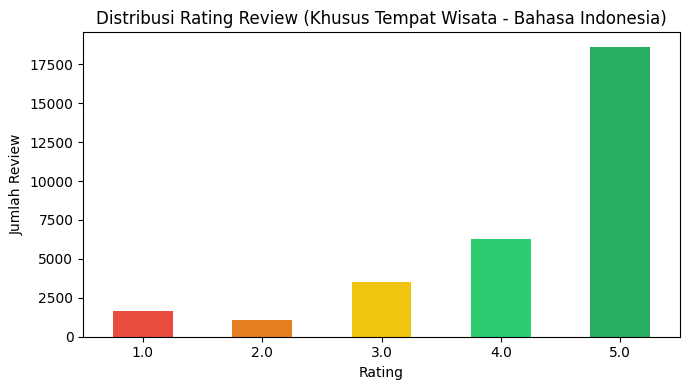

In [21]:
# Filter khusus ulasan bahasa Indonesia
df_id = df_tourist[df_tourist['original_language'] == 'id'].copy()
df_id = df_id.reset_index(drop=True)

print(f"Total review tempat wisata khusus bahasa Indonesia: {len(df_id):,} baris")

print("\n=== Distribusi Rating Tempat Wisata (Bahasa Indonesia) ===")
print(df_id['rating'].value_counts().sort_index())

# Visualisasi distribusi rating setelah pembersihan kategori
plt.figure(figsize=(7,4))
df_id['rating'].value_counts().sort_index().plot(kind='bar', color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60'])
plt.title('Distribusi Rating Review (Khusus Tempat Wisata - Bahasa Indonesia)')
plt.xlabel('Rating')
plt.ylabel('Jumlah Review')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Text Preprocessing

### Tahap Pembersihan dan Normalisasi Teks (*Text Preprocessing*)

Tahap ini merupakan proses krusial untuk membersihkan data teks mentah sebelum dimasukkan ke dalam model klasifikasi. Mengingat ulasan pengguna sering kali memuat bahasa tidak baku, *typo*, tulisan bergaya, dan karakter tidak relevan, *pipeline* pembersihan ini dirancang secara terpadu melalui beberapa langkah berikut:

**1. Integrasi Kamus Normalisasi (Slang & Typo)**
* Sistem memuat kamus kata baku dari sumber eksternal yang berisi pemetaan kata *slang* (informal) ke bentuk formalnya. 
* Data tersebut kemudian dikonversi menjadi struktur *dictionary* Python untuk memastikan pencarian dan penggantian kata berjalan dengan kompleksitas waktu yang sangat efisien.
* Terdapat ruang penyisipan kamus tambahan (`kamus_tambahan_wisata`) yang memungkinkan injeksi kata-kata spesifik domain secara fleksibel (misalnya: "mantab" diubah menjadi "mantap") tanpa harus mengubah file CSV sumber.

**2. Fungsi Pembersihan Utama (`preprocess`)**
Setiap baris ulasan akan melewati fungsi penyaringan ketat dengan urutan sebagai berikut:
* **Case Folding & Unicode Normalization:** Menyeragamkan seluruh huruf menjadi kecil (*lowercase*). Selanjutnya, metode `NFKD` (*Normalization Form Compatibility Decomposition*) dipadukan dengan penghapusan karakter *combining* untuk melucuti aksen (diakritik) serta menormalkan karakter/font unik kembali menjadi abjad Latin standar.
* **Pembersihan Noise (*Data Cleansing*):** Membuang elemen-elemen *noise* yang tidak memiliki kontribusi terhadap bobot sentimen, seperti tautan web (URL), *mention* (`@`), tagar (`#`), angka numerik, dan seluruh tanda baca (*punctuation*).
* **Reduksi Karakter Memanjang:** Menggunakan ekspresi reguler (Regex) untuk mendeteksi dan menormalkan huruf yang diketik berulang akibat penekanan emosi (contoh: mengubah "baguuuss" menjadi "bagus").
* **Substitusi Kosakata Baku:** Memecah teks menjadi token individu, lalu mencocokkan setiap kata dengan kamus normalisasi yang telah dibuat pada tahap awal.

**3. Eksekusi pada Dataset**
Seluruh *pipeline* pembersihan tersebut diaplikasikan ke kolom ulasan utama (`review_text`) menggunakan metode `.apply()`. Hasil akhirnya disimpan dalam kolom baru bernama `clean_text` yang menyajikan data bersih, terstandarisasi, dan bebas *noise* untuk diproses pada tahap selanjutnya.

In [22]:
import pandas as pd
import re
import string

# Muat file kamus kata baku gaul
path_kamus_baku = '/kaggle/input/datasets/nicodwiputra/normalisasi-slangtypo/kamuskatabaku (1).csv'
df_slang = pd.read_csv(path_kamus_baku)
kamus_normalisasi = dict(zip(df_slang['slang'], df_slang['formal']))

# --- 🎯 JALUR KHUSUS LEKSIKON: AGRESIF & BERSIH TANPA SIMBOL/ANGKA ---
def preprocess_for_lexicon(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)   # Hapus URL bersih
    text = re.sub(r'@\w+|#\w+', '', text)                 # Hapus Mention & Tagar
    text = re.sub(r'\d+', '', text)                       # Hapus Angka
    text = text.translate(str.maketrans('', '', string.punctuation))  # Hapus Tanda Baca
    text = re.sub(r'(.)\1{2,}', r'\1', text)              # Normalisasi kata memanjang
    words = text.split()
    words_normalized = [kamus_normalisasi[word] if word in kamus_normalisasi else word for word in words]
    return re.sub(r'\s+', ' ', " ".join(words_normalized)).strip()

# --- SKENARIO 1: BERT DENGAN NORMALISASI KATA GAUL (TEKS BAKU) ---
def S1_preprocess_bert(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', 'HTTPURL', text)   
    text = re.sub(r'@\w+', '@USER', text)                      
    text = re.sub(r'#\w+', '', text)         
    text = re.sub(r'(.)\1{2,}', r'\1', text)
    words = text.split()
    words_normalized = [kamus_normalisasi[word] if word in kamus_normalisasi else word for word in words]
    return re.sub(r'\s+', ' ', " ".join(words_normalized)).strip()

# --- SKENARIO 2: BERT TANPA NORMALISASI KATA GAUL (TEKS GAUL MENTAH) ---
def S2_preprocess_bert(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', 'HTTPURL', text)   
    text = re.sub(r'@\w+', '@USER', text)                      
    text = re.sub(r'#\w+', '', text)         
    text = re.sub(r'(.)\1{2,}', r'\1', text) 
    # Kamus normalisasi Sengaja Dihilangkan (Teks dibiarkan gaul/mentah)
    return re.sub(r'\s+', ' ', text).strip()

# --- Eksekusi Semua Jalur Kolom Terpisah ---
df_id['text_lexicon'] = df_id['review_text'].apply(preprocess_for_lexicon) # 💡 Ini untuk melayani Cell 7, 8, dan 9
df_id['S1_text_bert'] = df_id['review_text'].apply(S1_preprocess_bert)
df_id['S2_text_bert'] = df_id['review_text'].apply(S2_preprocess_bert)

print("✅ Sukses menyiapkan kolom Leksikon murni, Skenario 1 (Baku), dan Skenario 2 (Gaul)!")


✅ Sukses memuat 4,344 kata normalisasi typo
✅ Tahap Dual-Pipeline Preprocessing selesai dengan aman!


## 6.1 Visualisasi

In [23]:
print("=== CONTOH PREPROCESSING ===")

for i in range(10):
    print(f"\nData ke-{i+1}")
    print("Asli  :", df_id['review_text'].iloc[i])
    print("Bersih:", df_id['text_lexicon'].iloc[i])

=== CONTOH PREPROCESSING ===

Data ke-1
Asli  : Trip Pertama 2026
Sumenep - Pamekasan
Hotelnya menyenangkan, bagus dan tanpa keluhan. Next klo liburan sama anak anak pasti pilih hotel ini, tq Front One 👍👍
Bersih: trip pertama sumenep pamekasan hotelnya menyenangkan bagus dan tanpa keluhan next kalau liburan sama anak anak pasti pilih hotel ini tq front one 👍👍

Data ke-2
Asli  : Sangat menyenangkan menginap di hotel Front One Pamekasan bersama keluarga.
Bersih: sangat menyenangkan menginap di hotel front one pamekasan bersama keluarga

Data ke-3
Asli  : Fun
Bersih: fun

Data ke-4
Asli  : Kalo ke pamekasan nginepnya y disini
Bersih: kalau ke pamekasan nginepnya ya disini

Data ke-5
Asli  : Rekomen deh nginep disini. Lokasinya strategis enak mau kemana”. Breakfast menunya juga banyak dan bervariatif. Fasilitas nyaman dan lengkap 💕
Bersih: rekomen deh nginep disini lokasinya strategis enak mau kemana” breakfast menunya juga banyak dan bervariatif fasilitas nyaman dan lengkap 💕

Data ke-6
A

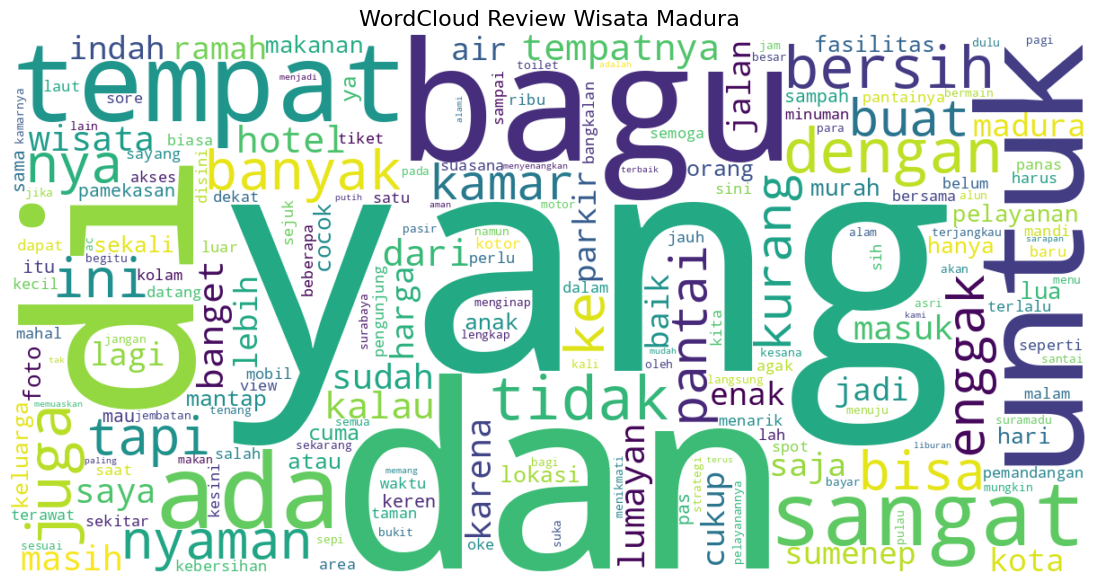

In [24]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Gabungkan seluruh teks
text_all = " ".join(df_id['text_lexicon'].astype(str))

# Generate wordcloud
wc = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    max_words=200,
    collocations=False
).generate(text_all)

# Visualisasi
plt.figure(figsize=(14,7))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.title("WordCloud Review Wisata Madura", fontsize=16)
plt.show()

In [25]:
from collections import Counter

top_words = Counter(
    " ".join(df_id['text_lexicon']).split()
).most_common(20)

df_top = pd.DataFrame(
    top_words,
    columns=['kata', 'frekuensi']
)

display(df_top)

,kata,frekuensi
0,yang,10723
1,dan,10486
2,di,8377
3,bagus,7347
4,untuk,5631
5,tempat,5525
6,ada,4903
7,sangat,3445
8,dengan,3321
9,juga,3232


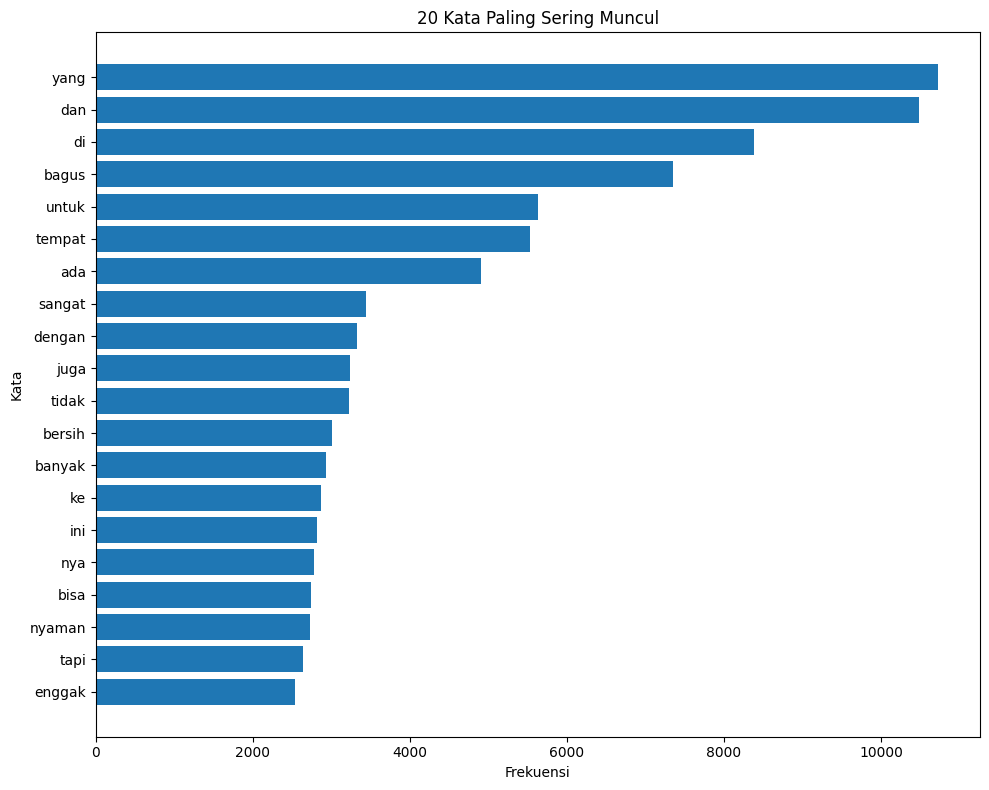

In [26]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

all_words = " ".join(df_id['text_lexicon']).split()

freq = Counter(all_words)

top20 = pd.DataFrame(
    freq.most_common(20),
    columns=['Kata','Frekuensi']
)

top20 = top20.sort_values('Frekuensi')

plt.figure(figsize=(10,8))
plt.barh(top20['Kata'], top20['Frekuensi'])
plt.xlabel('Frekuensi')
plt.ylabel('Kata')
plt.title('20 Kata Paling Sering Muncul')
plt.tight_layout()
plt.show()

## 7. Leksikon Otomatis

Daripada menggunakan nilai 3.0 sebagai batas ulasan netral, sistem menetapkan rata-rata asli seluruh dataset (yang biasanya tinggi, misalnya 4.2 karena orang jarang memberi bintang 1) sebagai Titik Nol (Netral) yang baru.

### Metode Pembobotan Leksikon: *Baseline Shifting*

Pembobotan sentimen untuk setiap kata kandidat diekstrak menggunakan pendekatan pemetaan rating secara proporsional. Untuk menangani ketidakseimbangan kelas (*imbalanced data*) yang didominasi oleh rating tinggi, nilai rata-rata rating dataset secara keseluruhan ditetapkan sebagai *baseline* (titik netral).

Sebelum melakukan pemetaan skala sentimen, sistem akan menghitung dua parameter statistik utama:

**1. Rata-rata Dataset ($\mu_{dataset}$)**
Merupakan nilai rata-rata (*mean*) dari *star rating* seluruh ulasan pariwisata di dalam dataset, dihitung dengan rumus:

$$\mu_{dataset} = \frac{1}{N} \sum_{i=1}^{N} R_i$$

*Keterangan: $N$ adalah total seluruh ulasan di dataset, dan $R_i$ adalah nilai rating pada ulasan ke-$i$.*

**2. Rata-rata Kata ($\mu_{kata}$)**
Merupakan nilai rata-rata rating spesifik yang hanya dihitung dari kumpulan ulasan yang memuat kata kandidat tertentu:

$$\mu_{kata} = \frac{1}{n} \sum_{j=1}^{n} r_j$$

*Keterangan: $n$ adalah jumlah ulasan yang mengandung kata tersebut, dan $r_j$ adalah nilai rating pada ulasan ke-$j$ yang memuat kata tersebut.*

**Ilustrasi Pencarian $\mu_{kata}$ (Contoh Kata: "kotor"):**
Mesin akan menyapu seluruh dataset dan mengumpulkan ulasan mana saja yang mengandung kata target. Misalkan mesin menemukan 4 ulasan:

| ID | Teks Ulasan | Rating Bintang |
| :--- | :--- | :--- |
| 01 | "Pantainya banyak sampah dan **kotor**." | 1 |
| 02 | "Tempatnya lumayan, tapi toiletnya **kotor**." | 3 |
| 03 | "Sangat **kotor** dan bau!" | 1 |
| 04 | "Fasilitas kurang terawat, agak **kotor**." | 2 |

Mesin menghitung rata-ratanya dengan menjumlahkan rating bintang lalu membaginya dengan jumlah ulasan:

$$\mu_{kotor} = \frac{1 + 3 + 1 + 2}{4} = \frac{7}{4} = 1.75$$

---

Setelah kedua nilai di atas didapatkan, bobot kata ($W$) dievaluasi dengan cara menguji nilai Rata-rata Kata terhadap *Baseline* (Rata-rata Dataset):

**A. Jika rata-rata kata berada di atas atau sama dengan *baseline* ($\mu_{kata} \ge \mu_{dataset}$):**
Pemetaan dilakukan ke dalam rentang skala positif (0 hingga 5).

$$W = \frac{\mu_{kata} - \mu_{dataset}}{5.0 - \mu_{dataset}} \times 5$$

**B. Jika rata-rata kata berada di bawah *baseline* ($\mu_{kata} < \mu_{dataset}$):**
Pemetaan dilakukan ke dalam rentang skala negatif (-5 hingga 0).

$$W = \frac{\mu_{kata} - \mu_{dataset}}{\mu_{dataset} - 1.0} \times 5$$

Nilai $W$ kemudian dibulatkan ke bilangan bulat terdekat dan dibatasi (*clipping*) agar selalu berada dalam rentang leksikon standar, yaitu $[-5, 5]$.

#### Contoh Simulasi Pembobotan Leksikon Final
Sebagai contoh, diasumsikan nilai rata-rata keseluruhan dataset ulasan pariwisata Madura adalah $\mu_{dataset} = 4.2$.

* **Kasus Sentimen Positif (Kata: "indah"):**
  Kata "indah" muncul pada ulasan dengan rata-rata rating $\mu_{kata} = 4.8$. Karena nilainya di atas *baseline* (4.8 > 4.2), maka dievaluasi menggunakan rumus pemetaan positif:

  $$W = \frac{4.8 - 4.2}{5.0 - 4.2} \times 5 = \frac{0.6}{0.8} \times 5 = 3.75$$

  Setelah dibulatkan, kata "indah" mendapatkan bobot leksikon sebesar **+4**.

* **Kasus Sentimen Negatif (Kata: "kotor"):**
  Berdasarkan ilustrasi sebelumnya, kata "kotor" memiliki nilai $\mu_{kata} = 1.75$. Karena berada di bawah *baseline* (1.75 < 4.2), maka dievaluasi menggunakan rumus pemetaan negatif:

  $$W = \frac{1.75 - 4.2}{4.2 - 1.0} \times 5 = \frac{-2.45}{3.2} \times 5 = -3.828$$

  Setelah dibulatkan, kata "kotor" mendapatkan bobot leksikon sebesar **-4**.

* **Kasus Kata Mengecoh (Kata: "tapi"):**
  Kata "tapi" sering muncul di ulasan dengan rating menengah, misalnya $\mu_{kata} = 3.8$. Meskipun secara nilai absolut angka 3.8 terkesan netral/positif, posisinya berada di bawah standar kepuasan umum pengunjung wisata (4.2).

  $$W = \frac{3.8 - 4.2}{4.2 - 1.0} \times 5 = \frac{-0.4}{3.2} \times 5 = -0.625$$

  Setelah dibulatkan, kata "tapi" secara objektif mendapatkan penalti berupa bobot **-1**. Hal ini membuktikan bahwa sistem mampu meredam *Leniency Bias* (kecenderungan rating tinggi yang menipu) secara matematis.

In [27]:
import re
import pandas as pd
from collections import Counter

# 1. Hitung frekuensi kemunculan kata di teks bersih
semua_kata = " ".join(df_id['text_lexicon']).split()
hitung_frekuensi = Counter(semua_kata)

# 🎯 KUNCI UTAMA: Hitung rata-rata rating riil seluruh dataset
rata_rating_dataset = df_id['rating'].mean() 
print(f"📊 Rata-rata rating baseline dataset: {rata_rating_dataset:.3f}")

data_kandidat = []
print("⏳ Menghitung statistik hubungan kata kandidat leksikon...")

# 2. Cari hubungan kata terhadap rating agregat dengan skala relatif
for kata, frekuensi in hitung_frekuensi.items():
    if frekuensi >= 7: 
        # Melakukan re.escape agar karakter khusus aman saat pencarian regex kata utuh
        ulasan_terkait = df_id[df_id['text_lexicon'].str.contains(rf'\b{re.escape(kata)}\b', regex=True, na=False)]
        
        if len(ulasan_terkait) > 0:
            rata_rating = ulasan_terkait['rating'].mean()
            
            # 🛠️ RUMUS BARU: Menghilangkan bias dominasi rating bintang 5
            if rata_rating >= rata_rating_dataset:
                # Rentang antara rata-rata dataset s.d 5.0 diubah menjadi skala 0 s.d 5
                bobot_otomatis = ((rata_rating - rata_rating_dataset) / (5.0 - rata_rating_dataset)) * 5
            else:
                # Rentang antara 1.0 s.d rata-rata dataset diubah menjadi skala -5 s.d 0
                bobot_otomatis = ((rata_rating - rata_rating_dataset) / (rata_rating_dataset - 1.0)) * 5
                
            bobot_otomatis = int(round(bobot_otomatis))
            bobot_otomatis = max(-5, min(5, bobot_otomatis)) # Kunci di batas aman
            
            data_kandidat.append({
                'kata': kata, 'frekuensi': frekuensi,
                'rata_rating_asal': round(rata_rating, 2), 'bobot_inset': bobot_otomatis
            })

df_kamus_otomatis = pd.DataFrame(data_kandidat)
print(f"✅ Sistem berhasil menemukan {len(df_kamus_otomatis):,} kata kandidat potensial.")

📊 Rata-rata rating baseline dataset: 4.257
⏳ Menghitung statistik hubungan kata kandidat leksikon...
✅ Sistem berhasil menemukan 3,608 kata kandidat potensial.


## 8. Kamus Lexicon

In [28]:
# Saring kata yang murni punya muatan emosi (bobot tidak sama dengan 0)
kamus_final = df_kamus_otomatis[df_kamus_otomatis['bobot_inset'] != 0].copy()
kamus_final = kamus_final.sort_values(by='bobot_inset', ascending=False).reset_index(drop=True)

kamus_final.to_csv('custom_inset_lexicon.csv', index=False)
print("💾 Berkas 'custom_inset_lexicon.csv'")

# print("\n🔥 SANGKUTAN KATA POSITIF TERATAS:")
# display(kamus_final.head(10))

# print("\n❄️ SANGKUTAN KATA NEGATIF TERATAS:")
# display(kamus_final.tail(10))

💾 Berkas 'custom_inset_lexicon.csv'


### Hapus noise seperti nama orang, tempat, dll

In [29]:
from pathlib import Path
import pandas as pd
import re
import unicodedata

# gunakan hasil Cell 8
df = kamus_final.copy()

# def normalize_word(text):
#     s = str(text).strip().lower()
#     s = unicodedata.normalize("NFKD", s)
#     s = "".join(ch for ch in s if not unicodedata.combining(ch))
#     return s

# df["kata"] = df["kata"].astype(str).apply(normalize_word)

# hanya huruf latin
df = df[df["kata"].str.fullmatch(r"[a-z]+", na=False)]

# minimal 3 karakter
df = df[df["kata"].str.len() >= 3]

# # hapus nama tempat / brand / orang
remove_words = {
    "dewi","aldi","dedy","alvira",
    "travelindo","namiroh","safira","arminareka",
    "gili","sapudi","labak","jokotole","karaton",
    "city","presiden","kbihu","cangga",
    "rato","prima","generasi","bandara",
    "hubungan","eduwisata","mas","beliau","iyang",
    "trunojoyo","myze","runcing",
    "insyaallah","islam","sajadah","ilmu",
    "place","style","hidden","nan","menyimpan",
    "perjuangan","batiknya",
    "aplikasi","pesanan","pembayaran","alasan","niat","kamar","suroboyo","kelahiran","kakak"
}

# df = df[~df["kata"].isin(remove_words)]

# minimal frekuensi
df = df[df["frekuensi"] >= 7]

# gabungkan duplikat
df = (
    df.groupby("kata", as_index=False)
      .agg({
          "frekuensi":"sum",
          "rata_rating_asal":"mean",
          "bobot_inset":"max"
      })
)

# urutkan
df = df.sort_values(
    ["bobot_inset","frekuensi"],
    ascending=[False,False]
)

kamus_final = df.reset_index(drop=True)

print("Jumlah kata setelah cleaning:", len(kamus_final))

display(kamus_final.head(20))

Jumlah kata setelah cleaning: 2496


,kata,frekuensi,rata_rating_asal,bobot_inset
0,gili,143,4.93,5
1,insyaallah,31,4.97,5
2,namiroh,24,4.93,5
3,karaton,22,5.00,5
4,ternyaman,21,5.00,5
5,jokotole,19,5.00,5
6,alvira,16,5.00,5
7,generasi,15,5.00,5
8,dewi,14,5.00,5
9,cangga,13,5.00,5


bobot_inset
-5      1
-4     15
-3     72
-2    261
-1    855
 1    471
 2    381
 3    224
 4    152
 5     64
Name: count, dtype: int64


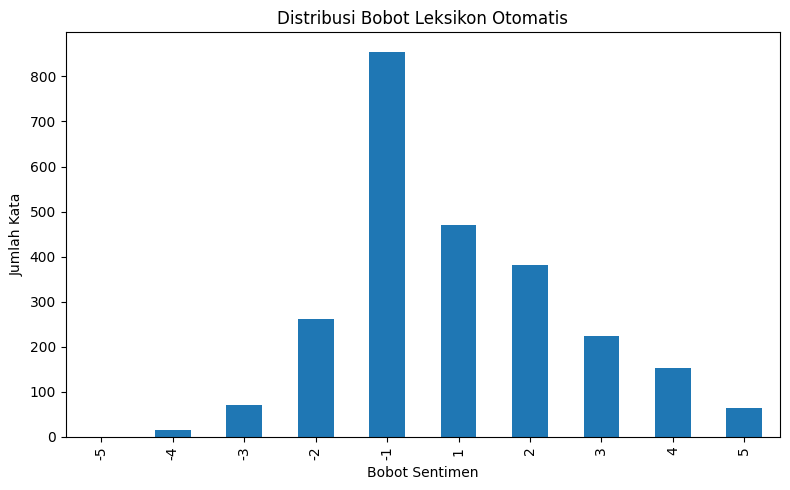

In [30]:
print(kamus_final['bobot_inset'].value_counts().sort_index())

plt.figure(figsize=(8,5))

kamus_final['bobot_inset'].value_counts().sort_index().plot(
    kind='bar'
)

plt.title('Distribusi Bobot Leksikon Otomatis')
plt.xlabel('Bobot Sentimen')
plt.ylabel('Jumlah Kata')
plt.tight_layout()
plt.show()

In [31]:
print("=== TOP 20 POSITIF ===")
display(
    kamus_final.sort_values(
        'bobot_inset',
        ascending=False
    ).head(20)
)

print("=== TOP 20 NEGATIF ===")
display(
    kamus_final.sort_values(
        'bobot_inset'
    ).head(20)
)

=== TOP 20 POSITIF ===


,kata,frekuensi,rata_rating_asal,bobot_inset
0,gili,143,4.93,5
1,insyaallah,31,4.97,5
2,namiroh,24,4.93,5
3,karaton,22,5.00,5
4,ternyaman,21,5.00,5
5,jokotole,19,5.00,5
6,alvira,16,5.00,5
7,generasi,15,5.00,5
8,dewi,14,5.00,5
9,cangga,13,5.00,5


=== TOP 20 NEGATIF ===


,kata,frekuensi,rata_rating_asal,bobot_inset
2495,marah,18,1.00,-5
2480,buruk,94,1.52,-4
2490,kas,7,1.86,-4
2488,apk,8,1.86,-4
2491,ngotak,7,1.71,-4
2492,seenaknya,7,1.50,-4
2493,tindakan,7,1.86,-4
2489,alasannya,7,1.43,-4
2484,bukannya,12,1.83,-4
2481,jorok,39,1.79,-4


## 9. Labelling

### Pelabelan Sentimen Berbasis Leksikon dengan Penanganan Negasi (1-Word Window)

Setelah kamus leksikon (*Lexicon Dictionary*) berhasil diekstrak dan dibobotkan, tahap selanjutnya adalah mengaplikasikan kamus tersebut untuk melabeli seluruh dataset ulasan secara otomatis (Otomasi Pelabelan Data Latih). 

Proses perhitungan skor sentimen pada tahap ini dirancang agar sensitif terhadap pembalikan makna akibat kata negasi (seperti *"tidak"*, *"bukan"*, *"gak"*). Berikut adalah alur kerja fungsi pelabelan tersebut:

**1. Pemetaan Kamus Akses Cepat (*Dictionary Mapping*)**
* DataFrame `kamus_final` dikonversi menjadi struktur data `dictionary` bawaan Python. Langkah ini sangat krusial untuk efisiensi komputasi, karena pencarian kata (*lookup*) pada *dictionary* memiliki kompleksitas waktu $O(1)$, jauh lebih efisien dibandingkan iterasi pencarian di dalam DataFrame.

**2. Tokenisasi dan Evaluasi Kata**
* Setiap kalimat ulasan yang sudah bersih (`clean_text`) dipecah menjadi token-token kata tunggal menggunakan spasi sebagai pemisah (`split()`). Sistem kemudian melakukan iterasi untuk membaca kata tersebut satu per satu dari kiri ke kanan.
* Jika kata yang sedang dievaluasi eksis di dalam `kamus_inset_custom`, sistem akan mengekstrak bobot sentimen aslinya.

**3. Evaluasi *Lookback Window* untuk Pembalikan Polaritas**
Ini merupakan fitur utama penanganan konteks. Ketika sistem menemukan kata sentimen, sistem tidak langsung menjumlahkan nilainya secara mentah.
* Sistem akan melihat mundur tepat **1 kata sebelumnya** (*1-word lookback window*) menggunakan rentang `max(0, i - 1)`.
* Sistem mengecek apakah kata di sebelah kiri tersebut termasuk dalam himpunan kata negasi standar Indonesia (*tidak, tak, bukan, gak, ga, nggak, enggak*).
* Jika terdeteksi adanya kata negasi, sistem akan melakukan pembalikan polaritas (*polarity inversion*), di mana skor aslinya akan dikalikan negatif (`skor = -skor`). Contoh: kata "mahal" (bernilai negatif) yang didahului kata "tidak" akan berbalik menjadi bermuatan positif.

**4. Agregasi Skor dan Penentuan Kelas Target (*Thresholding*)**
Setelah seluruh kata dalam satu ulasan dievaluasi dan bobot negasinya disesuaikan, sistem mengagregasikan total skornya (`total_skor`). Label kelas (*ground truth*) diinterpretasikan berdasarkan *threshold* berikut:
* **Positif:** Jika total akumulasi skor $> 0$.
* **Negatif:** Jika total akumulasi skor $< 0$.
* **Netral:** Jika total akumulasi skor $= 0$ (terjadi apabila tidak ada kata leksikon yang cocok, atau total bobot positif dan negatif saling menetralkan secara seimbang).

Fungsi ini kemudian dieksekusi ke seluruh baris dataset menggunakan metode `.apply()`, menghasilkan kolom target `label` yang akan menjadi variabel dependen (*target class*) pada pemodelan arsitektur Transformer selanjutnya.

In [32]:
# Transformasikan DataFrame kamus menjadi dictionary pemetaan cepat
kamus_inset_custom = dict(zip(kamus_final['kata'], kamus_final['bobot_inset']))

def hitung_sentimen_murni_leksikon(text):
    words = str(text).split()
    total_skor = 0

    kata_negasi = {
        'tidak', 'tak', 'bukan',
        'gak', 'ga', 'nggak', 'enggak'
    }

    for i, word in enumerate(words):

        if word in kamus_inset_custom:
            skor = kamus_inset_custom[word]

            # cek 2 kata sebelumnya
            window_awal = max(0, i - 1)
            konteks = words[window_awal:i]

            if any(kata in kata_negasi for kata in konteks):
                skor = -skor

            total_skor += skor

    if total_skor > 0:
        return 'positif'
    elif total_skor < 0:
        return 'negatif'
    else:
        return 'netral'

# Eksekusi penentuan label kelas target sentimen ulasan
df_id['label'] = df_id['text_lexicon'].apply(hitung_sentimen_murni_leksikon)

print("=== DISTRIBUSI KELAS SENTIMEN DATASET BARU ===")
print(df_id['label'].value_counts())

print("\nSampel Hasil Pelabelan:")
display(df_id[['text_lexicon', 'label']].head(10))

=== DISTRIBUSI KELAS SENTIMEN DATASET BARU ===
label
positif    20276
negatif     8012
netral      2846
Name: count, dtype: int64

Sampel Hasil Pelabelan:


,text_lexicon,label
0,trip pertama sumenep pamekasan hotelnya menyen...,positif
1,sangat menyenangkan menginap di hotel front on...,positif
2,fun,positif
3,kalau ke pamekasan nginepnya ya disini,positif
4,rekomen deh nginep disini lokasinya strategis ...,positif
5,kamar bersih sekali dan luas,positif
6,kamar bersih proses cek im cepat breakfast ena...,positif
7,hotelnya bagus sejuk pokoknya mantap lain kali...,positif
8,khusus untuk acara berapa biaya booking ballro...,positif
9,hotelnya bersih dan nyaman,positif


In [33]:
print(kamus_final['bobot_inset'].value_counts().sort_index())

bobot_inset
-5      1
-4     15
-3     72
-2    261
-1    855
 1    471
 2    381
 3    224
 4    152
 5     64
Name: count, dtype: int64


## 10. Split Data

### Pembagian Dataset (Data Splitting): Train, Validation, dan Test

Untuk melatih dan mengevaluasi model klasifikasi *Deep Learning* secara objektif, dataset dipartisi menjadi tiga sub-himpunan independen menggunakan proporsi **80:10:10**. Pembagian ini dilakukan secara proporsional (*stratified*) menggunakan `stratify=y` untuk memastikan rasio kelas (Positif, Negatif, Netral) tetap seimbang dan representatif di setiap partisi.

**1. Data Latih (Train Data - 80%)**
Merupakan porsi data terbesar yang digunakan secara langsung oleh model (IndoBERT/IndoBERTweet) pada fase *training*. Pada himpunan data ini, model melakukan iterasi pembaruan bobot parameter (*weight update*) melalui proses *backpropagation* untuk mempelajari pola dan korelasi antara teks ulasan dan label sentimennya.

**2. Data Validasi (Validation Data - 10%)**
Berfungsi sebagai data pengujian internal (*unbiased evaluation*) yang dieksekusi setiap kali satu *Epoch* pelatihan selesai. Data validasi memiliki dua peran krusial:
* **Deteksi Overfitting:** Memastikan bahwa model mampu melakukan generalisasi, bukan sekadar menghafal (*memorizing*) himpunan Data Latih.
* **Model Checkpointing:** Mengukur metrik *Validation Loss* (Loss Val). Jika model menunjukkan penurunan error validasi pada suatu iterasi, bobot model tersebut akan diamankan sebagai bobot terbaik (*Best Model*).

**3. Data Uji (Test Data - 10%)**
Merupakan himpunan data yang sepenuhnya diisolasi selama fase pelatihan dan validasi. Data ini baru akan diproses pada tahap inferensi akhir untuk mengukur metrik evaluasi objektif (seperti *Accuracy, Precision, Recall*, dan *F1-Score*) guna merepresentasikan performa model ketika dihadapkan pada teks ulasan tak terlihat (*unseen data*) di dunia nyata.

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

# 1. Siapkan Target y universal (Copy Label dari Leksikon Baku)
y_all = df_id['label'].map({'negatif': 0, 'netral': 1, 'positif': 2}).values

# 2. Ambil teks untuk masing-masing skenario
X_s1_all = df_id['S1_text_bert'].values # Teks Baku
X_s2_all = df_id['S2_text_bert'].values # Teks Gaul

# 3. Dapatkan indeks acak yang ter-stratifikasi (dikunci pakai random_state)
indeks_semua = np.arange(len(df_id))
idx_train, idx_temp = train_test_split(
    indeks_semua, test_size=0.20, random_state=42, stratify=y_all
)
idx_val, idx_test = train_test_split(
    idx_temp, test_size=0.50, random_state=42, stratify=y_all[idx_temp]
)

# 4. Pecah Fitur X untuk Skenario 1 (Baku)
X_train_s1, y_train = X_s1_all[idx_train], y_all[idx_train]
X_val_s1, y_val     = X_s1_all[idx_val], y_all[idx_val]
X_test_s1, y_test   = X_s1_all[idx_test], y_all[idx_test]

# 5. Pecah Fitur X untuk Skenario 2 (Gaul) Menggunakan Indeks yang Sama Persis (Copy Label)
X_train_s2 = X_s2_all[idx_train]
X_val_s2   = X_s2_all[idx_val]
X_test_s2  = X_s2_all[idx_test]

print("📊 DATA SPLITTING OTOMATIS 2 SKENARIO SELESAI!")
print(f"   - Ukuran Data Latih (Train) : {X_train_s1.shape[0]:,} sampel")
print(f"   - Ukuran Data Validasi (Val) : {X_val_s1.shape[0]:,} sampel")
print(f"   - Ukuran Data Uji (Test)     : {X_test_s1.shape[0]:,} sampel")


In [34]:
from sklearn.model_selection import train_test_split

# Pisahkan fitur (teks bersih) dan target (label sentimen)
X = df_id['text_bert'].values
y = df_id['label'].map({'negatif': 0, 'netral': 1, 'positif': 2}).values

# Split pertama: 80% Train, 20% Temporary (untuk Val & Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Split kedua: Bagi data temporary menjadi 50% Validation dan 50% Testing (masing-masing 10% dari total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"📊 Ukuran Data Latih (Train) : {X_train.shape[0]:,} sampel")
print(f"📊 Ukuran Data Validasi (Val) : {X_val.shape[0]:,} sampel")
print(f"📊 Ukuran Data Uji (Test)     : {X_test.shape[0]:,} sampel")

📊 Ukuran Data Latih (Train) : 24,907 sampel
📊 Ukuran Data Validasi (Val) : 3,113 sampel
📊 Ukuran Data Uji (Test)     : 3,114 sampel


## 11. Menghitung Bobot Kelas (Class Weights)

### Penanganan Ketidakseimbangan Kelas (*Class Weighting*)

Tantangan utama dalam pemrosesan bahasa alami pada dataset *User-Generated Content* (ulasan pariwisata) adalah ketidakseimbangan distribusi kelas (*imbalanced data*). Ulasan bersentimen Positif umumnya memiliki frekuensi kemunculan yang jauh lebih dominan dibandingkan kelas Negatif maupun Netral. Tanpa intervensi, model klasifikasi akan rentan mengalami bias kelas mayoritas, di mana model cenderung memprediksi kelas dominan untuk menekan nilai *error*, sehingga gagal mengenali pola pada kelas minoritas.

Untuk memitigasi anomali tersebut tanpa membuang data (seperti pada metode *undersampling*), diterapkan teknik pembobotan kelas (*Class Weighting*) pada saat fase pelatihan.

**1. Ekstraksi Bobot Proporsional (Scikit-Learn)**
Modul `compute_class_weight` dengan parameter konfigurasi `'balanced'` digunakan untuk mengkalkulasi bobot penalti secara otomatis berdasarkan frekuensi kemunculan data. Algoritma ini memberikan bobot yang berbanding terbalik dengan frekuensi kelas. Rumus heuristik yang diterapkan adalah sebagai berikut:

$$W_c = \frac{N}{C \times n_c}$$

*Keterangan:*
* $W_c$ = Bobot kompensasi untuk kelas $c$
* $N$ = Total sampel keseluruhan pada himpunan Data Latih
* $C$ = Total variasi kelas target ($C = 3$)
* $n_c$ = Jumlah sampel aktual yang berada pada kelas $c$

**2. Integrasi Komputasi PyTorch (*Tensor Conversion*)**
Keluaran array dari Scikit-Learn kemudian dikonversi menjadi struktur data `torch.tensor` dengan presisi `torch.float`. Konversi ini diwajibkan agar vektor bobot tersebut dapat disuntikkan secara langsung sebagai parameter pengali pada fungsi evaluasi kerugian (*Loss Function*) bawaan PyTorch, yaitu `CrossEntropyLoss`.

**3. Implikasi pada Pembaruan Bobot Model**
Melalui injeksi *Class Weights* ini, fungsi kerugian akan memberikan penalti (*loss*) yang dikalikan dengan bobot kelas yang bersangkutan. Akibatnya, ketika arsitektur Transformer (IndoBERT/IndoBERTweet) melakukan misklasifikasi pada kelas minoritas (misalnya: Negatif), model akan menerima lonjakan *loss* yang jauh lebih masif dibandingkan ketika melakukan kesalahan pada kelas mayoritas (Positif). Mekanisme ini secara efektif memaksa model untuk memusatkan perhatian lebih ekstra dalam merepresentasikan fitur dari kelas yang langka.

In [35]:
import torch
from sklearn.utils.class_weight import compute_class_weight

# Hitung bobot kelas secara otomatis menggunakan scikit-learn
weights = compute_class_weight(
    class_weight='balanced', 
    classes=np.unique(y_train), 
    y=y_train
)

# Konversikan menjadi PyTorch Tensor agar siap dimasukkan ke fungsi Loss (CrossEntropyLoss)
class_weights = torch.tensor(weights, dtype=torch.float)

print("=== BOBOT PENALTI KELAS (CLASS WEIGHTS) ===")
print(f" - Bobot Kelas 0 [Negatif] : {class_weights[0].item():.4f}")
print(f" - Bobot Kelas 1 [Netral]  : {class_weights[1].item():.4f}")
print(f" - Bobot Kelas 2 [Positif] : {class_weights[2].item():.4f}")

=== BOBOT PENALTI KELAS (CLASS WEIGHTS) ===
 - Bobot Kelas 0 [Negatif] : 1.2954
 - Bobot Kelas 1 [Netral]  : 3.6462
 - Bobot Kelas 2 [Positif] : 0.5118


## 12. Modelling

## 12.1. Tokenizer

### Tokenisasi Teks dan Manajemen Input PyTorch (*Data Loading*)

Sebelum korpus ulasan pariwisata dapat dikomputasi oleh model *Deep Learning* berbasis Transformer (IndoBERT/IndoBERTweet), teks mentah harus dikonversi menjadi representasi numerik (tensor) dan dibungkus ke dalam ekosistem PyTorch. Modul kode ini menangani dua krusial tersebut melalui proses berikut:

**1. Transformasi Tokenisasi Terstruktur (`AutoTokenizer`)**
* Modul pemanggil `AutoTokenizer.from_pretrained` akan mengunduh dan menyelaraskan konfigurasi kosakata (*vocabulary*) agar sama persis dengan yang digunakan oleh model pralahir. Parameter `use_fast=True` mengaktifkan implementasi berbasis *Rust* untuk mempercepat eksekusi pemotongan kata.
* **Standarisasi Dimensi:** Model arsitektur BERT mewajibkan ukuran dimensi masukan yang seragam (statis). Oleh karena itu, diterapkan kombinasi `truncation=True` (untuk memotong kalimat yang lebih panjang dari batas maksimal) dan `padding=True` (untuk menyisipkan token `[PAD]` pada kalimat yang pendek). Batas panjang kalimat (*sequence length*) ditetapkan secara moderat pada `MAX_LEN = 128` token.

**2. Pembungkusan Kelas Dataset (`UlasanPariwisataDataset`)**
* Kelas ini dibangun sebagai turunan (*inheritance*) dari `torch.utils.data.Dataset`. Kelas ini mendefinisikan bagaimana mesin mengekstrak setiap baris data per indeks.
* Pada *magic method* `__getitem__`, seluruh nilai *dictionary* hasil tokenisasi (seperti *input_ids* dan *attention_mask*) dikonversi menjadi matriks matematis `torch.tensor`. 
* Perhatian khusus diberikan pada variabel `labels` yang secara eksplisit di-casting ke dalam format presisi `torch.long`. Format *long integer* ini adalah syarat mutlak bawaan mesin PyTorch agar target target multikelas dapat dievaluasi secara valid oleh fungsi kerugian *Cross Entropy Loss*.

**3. Fragmentasi Komputasi dengan `DataLoader`**
* Menyuapkan belasan ribu matriks teks secara bersamaan akan memicu beban komputasi yang mustahil ditangani oleh unit pemrosesan grafis (GPU). Modul `DataLoader` mengintervensi dengan memecah dataset ke dalam subset-subset berukuran statis (*mini-batch*).
* Penentuan parameter `batch_size=16` merupakan sebuah strategi alokasi memori yang optimal. Ukuran ini memastikan beban pelatihan tetap stabil dan mencegah terjadinya *crash* akibat kehabisan memori VRAM (*Out of Memory*), terutama saat arsitektur Transformer dieksekusi pada lingkungan GPU standar dengan keterbatasan kapasitas ruang VRAM di kelas 4GB.
* **Mekanisme Pengacakan (*Stochasticity*):** Parameter `shuffle=True` diaktifkan secara eksklusif pada Data Latih (`train_loader`) guna mengacak distribusi data pada setiap siklus *Epoch*, mencegah model mengalami *overfitting* akibat menghafal pola urutan. Sebaliknya, parameter tersebut dimatikan (`shuffle=False`) pada Data Validasi dan Uji untuk menjaga konsistensi metrik pengujian.

In [36]:
from torch.utils.data import Dataset, DataLoader
import torch

class UlasanPariwisataDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

def siapkan_dataloader(model_name, X_train, X_val, X_test, y_train, y_val, y_test, batch_size=64):
    print(f"⏳ Memuat Tokenizer untuk: {model_name}...")
    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    
    MAX_LEN = 128
    print("⏳ Melakukan tokenisasi korpus teks...")
    train_encodings = tokenizer(list(X_train), truncation=True, padding=True, max_length=MAX_LEN)
    val_encodings   = tokenizer(list(X_val), truncation=True, padding=True, max_length=MAX_LEN)
    test_encodings  = tokenizer(list(X_test), truncation=True, padding=True, max_length=MAX_LEN)
    
    train_dataset = UlasanPariwisataDataset(train_encodings, y_train)
    val_dataset   = UlasanPariwisataDataset(val_encodings, y_val)
    test_dataset  = UlasanPariwisataDataset(test_encodings, y_test)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    print(f"✅ DataLoader untuk {model_name} SIAP!\n")
    return train_loader, val_loader, test_loader

## 12.2. Fungsi train dan Evaluasi Model Transformer

### Siklus Pelatihan (*Training Loop*) dan Evaluasi Model

Fungsi `train_dan_evaluasi_model` merupakan inti komputasi dari proses *Fine-Tuning* arsitektur Transformer. Fungsi ini merangkum seluruh tahapan iterasi pembelajaran, optimasi bobot, hingga penyimpanan model terbaik (*Model Checkpointing*). 

Secara arsitektural, proses ini dibagi menjadi beberapa komponen krusial:

**1. Inisialisasi Hyperparameter dan Fungsi Objektif**
* **Arsitektur Model:** Modul `AutoModelForSequenceClassification` memuat arsitektur dasar Transformer dengan menambahkan lapisan klasifikasi (*linear layer*) di bagian ujung (*head*) yang dikonfigurasi untuk 3 kelas keluaran (`num_labels=3`).
* **Fungsi Kerugian (*Loss Function*):** Menggunakan `CrossEntropyLoss` yang telah diinjeksi dengan tensor `class_weights`. Hal ini memaksa model untuk memberikan penalti gradien yang lebih masif saat melakukan kesalahan pada prediksi kelas minoritas.
* **Optimasi (AdamW & Scheduler):** Algoritma AdamW (Adam dengan *Weight Decay*) digunakan untuk memperbarui parameter jaringan, dipadukan dengan *Linear Learning Rate Scheduler*. Fitur *Warmup* menginstruksikan model untuk beradaptasi dengan *learning rate* rendah di 10% langkah awal guna mencegah ketidakstabilan gradien (*gradient explosion*).

**2. Efisiensi Komputasi (*Automatic Mixed Precision / AMP*)**
Mengingat beban memori VRAM GPU yang sangat masif saat melatih model BERT, diterapkan teknik optimasi memori menggunakan modul `autocast` dan `GradScaler`. AMP memungkinkan operasi matematika tertentu dieksekusi menggunakan presisi 16-bit (FP16) alih-alih 32-bit standar (FP32). Hal ini mempercepat waktu komputasi secara signifikan dan menekan konsumsi memori tanpa mendegradasi akurasi metrik akhir.

**3. Fase Pelatihan (*Forward & Backward Propagation*)**
Pada setiap *Epoch*, model masuk ke mode pelatihan (`model.train()`). Data latih disuapkan per *batch*. Model melakukan *forward pass* untuk memprediksi label sentimen, menghitung nilai *Loss*, lalu melakukan *backward pass* (propagasi balik) melalui `scaler.scale(loss).backward()` untuk mengalkulasi dan menerapkan pembaruan bobot pada setiap *layer* *neural network*.

**4. Fase Validasi dan Evaluasi Metrik**
Setelah satu *Epoch* pelatihan selesai, model dibekukan dari pembaruan gradien menggunakan pembungkus `torch.no_grad()` dan dipindah ke mode evaluasi (`model.eval()`). Model kemudian diuji menggunakan Data Validasi untuk mengukur performa generalisasinya secara objektif. Metrik performa yang diekstraksi meliputi *Validation Loss*, Akurasi, dan *Macro F1-Score*.

**5. *Model Checkpointing* (Penyimpanan Bobot Terbaik)**
Untuk memitigasi risiko *Overfitting* (kondisi di mana model hanya menghafal data latih namun gagal mengenali data baru), diimplementasikan algoritma *Checkpointing* berbasis *Validation Loss*. Sistem melacak variabel `best_val_loss` pada setiap *Epoch*. Jika *Loss* tervalidasi menurun (mengindikasikan model menjadi lebih pintar), bobot jaringan (*state_dict*) akan diduplikasi ke memori utama (`copy.deepcopy`) dan disimpan secara fisik ke disk (ekstensi `.pt`). Pada akhir iterasi, fungsi ini akan mengembalikan versi model terbaik, mengabaikan degradasi bobot yang mungkin terjadi di *Epoch* terakhir.

In [37]:
import os
import copy
import time
import gc
import torch
from sklearn.metrics import accuracy_score, f1_score
from transformers import AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW  
from torch.cuda.amp import autocast, GradScaler

def train_dan_evaluasi_model(model_name, train_loader, val_loader, class_weights, epochs=7, lr=1e-5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"🚀 Memulai Pemodelan untuk: {model_name}")
    
    # 1. Inisialisasi Model
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)
    model.to(device)
    
    # Loss Function dengan Bobot Penalti Kelas
    criterion = torch.nn.CrossEntropyLoss(weight=class_weights.to(device))
    
    # Optimizer dengan weight decay tingkat lanjut untuk menekan overfitting
    optimizer = AdamW(model.parameters(), lr=lr)
    
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer, 
        num_warmup_steps=int(0.1 * total_steps), 
        num_training_steps=total_steps
    )
    scaler = GradScaler()
    
    # --- Variabel Pelacak Model Terbaik ---
    best_val_loss = float('inf')
    best_model_weights = None
    best_epoch = 1
    # Buat nama file save yang aman dari karakter path/slug
    nama_file_save = f"best_model_{model_name.replace('/', '_')}.pt"
    
    # 2. Training Loop
    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        
        for batch in train_loader:
            optimizer.zero_grad()
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            with autocast():
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                loss = criterion(outputs.logits, labels)
                
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            total_train_loss += loss.item()
            
        # 3. Validation Tahap
        model.eval()
        total_val_loss = 0
        preds_all, labels_all = [], []
        
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                
                with autocast():
                    outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                    loss = criterion(outputs.logits, labels)
                    
                total_val_loss += loss.item()
                preds = torch.argmax(outputs.logits, dim=1).flatten().cpu().numpy()
                preds_all.extend(preds)
                labels_all.extend(labels.cpu().numpy())
                
        # Hitung Rata-rata Loss dan Metrik
        avg_train_loss = total_train_loss / len(train_loader)
        avg_val_loss = total_val_loss / len(val_loader)
        acc = accuracy_score(labels_all, preds_all)
        macro_f1 = f1_score(labels_all, preds_all, average='macro')
        
        # --- Logika Penyimpanan Bobot Terbaik ---
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_epoch = epoch + 1
            # Menggandakan bobot state_dict ke memori CPU agar hemat VRAM saat looping berjalan
            best_model_weights = copy.deepcopy(model.state_dict())
            # Simpan juga ke Google Colab drive/lokal sebagai backup aman
            torch.save(best_model_weights, nama_file_save)
            status_save = f"✅ Model terbaik disimpan (Loss Val turun)"
        else:
            status_save = f"⚠️ Loss Val tidak membaik"
            
        print(f" Epoch [{epoch+1}/{epochs}] | Loss Latih: {avg_train_loss:.4f} | Loss Val: {avg_val_loss:.4f} | Acc Val: {acc*100:.2f}% | Macro F1 Val: {macro_f1*100:.2f}% | {status_save}")
        
    print(f"\n🏆 Proses Selesai! Mengembalikan model terbaik dari Epoch {best_epoch} dengan Loss Val: {best_val_loss:.4f}")
    
    # Memuat kembali bobot terbaik ke dalam model sebelum dikembalikan ke pipeline utama
    model.load_state_dict(best_model_weights)
    return model

## 12.3. Training Model

In [38]:
import transformers
transformers.logging.set_verbosity_error()

In [39]:
# List model yang akan dibandingkan sesuai repositori resmi Hugging Face
daftar_model = {
    'IndoBERT (indolem/indobert-base-uncased)': 'indolem/indobert-base-uncased',
    'IndoBERTweet (indolem/indobertweet-base-uncased)': 'indolem/indobertweet-base-uncased'
}

model_terlatih_dict = {}

for nama_label, path_model in daftar_model.items():
    print(f"\n==================================================================")
    print(f"⚙️ MEMULAI PIPELINE UNTUK: {nama_label}")
    print(f"==================================================================")
    
    # 1. Siapkan Dataloader spesifik untuk model tersebut
    train_ld, val_ld, test_ld = siapkan_dataloader(
        path_model, X_train, X_val, X_test, y_train, y_val, y_test, batch_size=16
    )
    
    # 2. Jalankan Fine-Tuning (Fungsi baru otomatis mengembalikan bobot terbaik dari epoch optimal)
    model_hasil = train_dan_evaluasi_model(
        path_model, train_ld, val_ld, class_weights, epochs=7, lr=1e-5
    )
    
    # 3. Simpan model terbaik ke dictionary untuk evaluasi akhir/bukan model epoch terakhir
    model_terlatih_dict[nama_label] = {
        'model': model_hasil,
        'test_loader': test_ld
    }
    
    # 4. MANAJEMEN MEMORI GPU (Pencegahan OOM/Crash)
    del model_hasil, train_ld, val_ld, test_ld
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print(f"✨ Sesi untuk {nama_label} selesai & Memori GPU dibersihkan.\n")


⚙️ MEMULAI PIPELINE UNTUK: IndoBERT (indolem/indobert-base-uncased)
⏳ Memuat Tokenizer untuk: indolem/indobert-base-uncased...


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

...

⏳ Melakukan tokenisasi korpus teks...
✅ DataLoader untuk indolem/indobertweet-base-uncased SIAP!

🚀 Memulai Pemodelan untuk: indolem/indobertweet-base-uncased


pytorch_model.bin:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

 Epoch [1/7] | Loss Latih: 0.7118 | Loss Val: 0.5143 | Acc Val: 81.43% | Macro F1 Val: 72.36% | ✅ Model terbaik disimpan (Loss Val turun)
 Epoch [2/7] | Loss Latih: 0.4314 | Loss Val: 0.4576 | Acc Val: 84.58% | Macro F1 Val: 75.67% | ✅ Model terbaik disimpan (Loss Val turun)
 Epoch [3/7] | Loss Latih: 0.3246 | Loss Val: 0.4852 | Acc Val: 86.96% | Macro F1 Val: 77.39% | ⚠️ Loss Val tidak membaik
 Epoch [4/7] | Loss Latih: 0.2439 | Loss Val: 0.5274 | Acc Val: 86.99% | Macro F1 Val: 77.93% | ⚠️ Loss Val tidak membaik
 Epoch [5/7] | Loss Latih: 0.1889 | Loss Val: 0.5912 | Acc Val: 87.38% | Macro F1 Val: 77.98% | ⚠️ Loss Val tidak membaik
 Epoch [6/7] | Loss Latih: 0.1541 | Loss Val: 0.6320 | Acc Val: 87.63% | Macro F1 Val: 78.31% | ⚠️ Loss Val tidak membaik
 Epoch [7/7] | Loss Latih: 0.1249 | Loss Val: 0.6349 | Acc Val: 88.02% | Macro F1 Val: 78.91% | ⚠️ Loss Val tidak membaik

🏆 Proses Selesai! Mengembalikan model terbaik dari Epoch 2 dengan Loss Val: 0.4576
✨ Sesi untuk IndoBERTweet (ind

## 13. Testing dan Metrik Evaluasi Model



In [40]:
from tqdm.auto import tqdm
# Tambahan import classification_report di sini
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import pandas as pd
import torch
from torch.cuda.amp import autocast

hasil_komparasi_ta = []
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

target_names = ['Negatif', 'Netral', 'Positif']

for nama_model, komponen in model_terlatih_dict.items():
    model = komponen['model']
    test_loader = komponen['test_loader']
    
    model.eval()
    preds_test, labels_test = [], []
    
    print(f"\n" + "="*60)
    print(f"🔎 MEMULAI PROSES TESTING: {nama_model}")
    print("="*60)
    
    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Mengevaluasi Batch"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            with autocast():
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                
            preds = torch.argmax(outputs.logits, dim=1).flatten().cpu().numpy()
            preds_test.extend(preds)
            labels_test.extend(labels.cpu().numpy())
            
    # ==========================================================
    # HASIL TESTING
    # ==========================================================
    print(f"\n📝 HASIL TESTING DETAIL ({nama_model}):")
    # Jika program error karena target_names tidak cocok jumlahnya, 
    # hapus parameter `target_names=target_names` di bawah ini.
    print(classification_report(labels_test, preds_test, target_names=target_names, zero_division=0))
    
    # Kalkulasi Metrik Komparasi Final untuk dimasukkan ke Tabel
    accuracy = accuracy_score(labels_test, preds_test)
    precision = precision_score(labels_test, preds_test, average='macro', zero_division=0)
    recall = recall_score(labels_test, preds_test, average='macro', zero_division=0)
    f1_macro = f1_score(labels_test, preds_test, average='macro', zero_division=0)
    
    hasil_komparasi_ta.append({
        'Model Arsitektur': nama_model,
        'Accuracy': f1_macro if accuracy > 1.0 else accuracy, 
        'Precision (Macro)': precision,
        'Recall (Macro)': recall,
        'F1-Score (Macro)': f1_macro
    })

# Tampilkan dalam bentuk DataFrame untuk tabel Bab 4
df_komparasi_final = pd.DataFrame(hasil_komparasi_ta)
print("\n" + "="*60)
print("TABEL KOMPARASI AKHIR ")
print("="*60)
display(df_komparasi_final.round(4))


🔎 MEMULAI PROSES TESTING: IndoBERT (indolem/indobert-base-uncased)


Mengevaluasi Batch:   0%|          | 0/195 [00:00<?, ?it/s]


📝 HASIL TESTING DETAIL (IndoBERT (indolem/indobert-base-uncased)):
              precision    recall  f1-score   support

     Negatif       0.88      0.86      0.87       802
      Netral       0.47      0.69      0.56       284
     Positif       0.96      0.91      0.94      2028

    accuracy                           0.88      3114
   macro avg       0.77      0.82      0.79      3114
weighted avg       0.90      0.88      0.89      3114


🔎 MEMULAI PROSES TESTING: IndoBERTweet (indolem/indobertweet-base-uncased)


Mengevaluasi Batch:   0%|          | 0/195 [00:00<?, ?it/s]


📝 HASIL TESTING DETAIL (IndoBERTweet (indolem/indobertweet-base-uncased)):
              precision    recall  f1-score   support

     Negatif       0.82      0.91      0.86       802
      Netral       0.43      0.65      0.52       284
     Positif       0.97      0.86      0.91      2028

    accuracy                           0.85      3114
   macro avg       0.74      0.81      0.77      3114
weighted avg       0.88      0.85      0.86      3114


📊 TABEL KOMPARASI AKHIR (UNTUK LAPORAN REVISI DOSEN) 📊


,Model Arsitektur,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro)
0,IndoBERT (indolem/indobert-base-uncased),0.8776,0.7726,0.8197,0.7889
1,IndoBERTweet (indolem/indobertweet-base-uncased),0.8548,0.7416,0.8079,0.7652


In [ ]:
def prediksi_sentimen_kustom(text, path_model, model_obj):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # 1. Jalankan pra-pemrosesan teks (menggunakan fungsi preprocess dari Cell 6)
    text_bersih = preprocess_for_bert(text)
    
    # 2. Muat tokenizer khusus untuk model yang bersangkutan
    tokenizer = AutoTokenizer.from_pretrained(path_model, use_fast=True)
    
    # 3. Konversikan teks menjadi tensor ID numerik
    inputs = tokenizer(text_bersih, return_tensors="pt", truncation=True, padding=True, max_length=128)
    
    input_ids = inputs['input_ids'].to(device)
    attention_mask = inputs['attention_mask'].to(device)
    
    # 4. Mode evaluasi model (matikan fungsi dropout)
    model_obj.eval()
    with torch.no_grad():
        outputs = model_obj(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        # Ambil indeks kelas dengan probabilitas tertinggi
        pred_class = torch.argmax(logits, dim=1).item()
        
    # 5. Mapping indeks angka ke teks label sentimen
    label_map = {0: '🔴 NEGATIF', 1: '🟡 NETRAL', 2: '🟢 POSITIF'}
    return label_map[pred_class]

# ==================================================================
#                     PROSES INTERAKTIF TESTING
# ==================================================================
print("==================================================================")
print("       JENDELA TESTING SENTIMEN WISATA MADURA INTERAKTIF        ")
print("==================================================================")

# Masukkan teks ulasan pariwisata pariwisata yang ingin kamu uji bebas
ulasan_user = input("Ketik ulasan pariwisata Madura di sini: ")

if ulasan_user.strip() == "":
    print("Kamu belum mengetikkan ulasan apa pun!")
else:
    print("\n" + "="*50)
    print(f"Teks Ulasan: \"{ulasan_user}\"")
    print("="*50)
    print("HASIL PREDIKSI KOMPARASI KEDUA MODEL:")
    
    # Lakukan prediksi pada kedua model yang sudah tersimpan di memori dict Cell 14
    for nama_model, komponen in model_terlatih_dict.items():
        jalur_huggingface = daftar_model[nama_model]
        hasil_sentimen = prediksi_sentimen_kustom(ulasan_user, jalur_huggingface, komponen['model'])
        print(f" 🤖 {nama_model:<22} -> {hasil_sentimen}")
    print("="*50)

       JENDELA TESTING SENTIMEN WISATA MADURA INTERAKTIF        
